In [1]:
!pip install -q qiskit qiskit-aer matplotlib pandas pylatexenc

In [2]:
import qiskit
import qiskit_aer
import matplotlib
import pylatexenc

print("Qiskit version:", qiskit.__version__)
print("Qiskit Aer version:", qiskit_aer.__version__)
print("Matplotlib version:", matplotlib.__version__)
print("pylatexenc: installed successfully")

Qiskit version: 2.5.2
Qiskit Aer version: 0.17.2
Matplotlib version: 3.10.0
pylatexenc: installed successfully


In [3]:
!pip install -q pylatexenc

In [4]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator


def deutsch_jozsa(f, n, draw_circuit=False):

    # Create n input qubits + 1 ancilla qubit
    qc = QuantumCircuit(n + 1, n)

    ancilla = n

    # Step 1: Prepare ancilla in |1>
    qc.x(ancilla)

    # Step 2: Apply Hadamard gates
    qc.h(range(n + 1))

    qc.barrier()

    # Step 3: Oracle
    for x in range(2 ** n):

        if f(x) == 1:

            # Binary representation of x
            bits = format(x, f'0{n}b')

            # Convert controls for zero bits
            for i, bit in enumerate(bits):
                if bit == '0':
                    qc.x(i)

            # Multi-controlled NOT
            qc.mcx(list(range(n)), ancilla)

            # Undo X gates
            for i, bit in enumerate(bits):
                if bit == '0':
                    qc.x(i)

    qc.barrier()

    # Step 4: Hadamard gates on input register
    qc.h(range(n))

    # Step 5: Measurement
    qc.measure(range(n), range(n))

    # Display circuit WITHOUT Matplotlib
    if draw_circuit:
        print(qc.draw("text"))

    # Step 6: Run simulator
    simulator = AerSimulator()

    compiled_circuit = transpile(qc, simulator)

    result = simulator.run(
        compiled_circuit,
        shots=1024
    ).result()

    counts = result.get_counts()

    # Step 7: Deutsch-Jozsa decision
    zero_state = "0" * n

    if counts.get(zero_state, 0) == 1024:
        classification = "Constant"
    else:
        classification = "Balanced"

    return classification, counts, qc

In [5]:
def constant_zero(x):
    return 0


n = 3

classification, counts, circuit = deutsch_jozsa(
    constant_zero,
    n,
    draw_circuit=True
)

print("\nFunction type:", classification)
print("Measurement results:", counts)

     ┌───┐      ░  ░ ┌───┐┌─┐      
q_0: ┤ H ├──────░──░─┤ H ├┤M├──────
     ├───┤      ░  ░ ├───┤└╥┘┌─┐   
q_1: ┤ H ├──────░──░─┤ H ├─╫─┤M├───
     ├───┤      ░  ░ ├───┤ ║ └╥┘┌─┐
q_2: ┤ H ├──────░──░─┤ H ├─╫──╫─┤M├
     ├───┤┌───┐ ░  ░ └───┘ ║  ║ └╥┘
q_3: ┤ X ├┤ H ├─░──░───────╫──╫──╫─
     └───┘└───┘ ░  ░       ║  ║  ║ 
c: 3/══════════════════════╩══╩══╩═
                           0  1  2 

Function type: Constant
Measurement results: {'000': 1024}


In [6]:
def parity_function(x):
    return bin(x).count("1") % 2


n = 3

classification, counts, circuit = deutsch_jozsa(
    parity_function,
    n,
    draw_circuit=True
)

print("\nFunction type:", classification)
print("Measurement results:", counts)

     ┌───┐      ░ ┌───┐     ┌───┐┌───┐     ┌───┐                     ░ ┌───┐┌─┐»
q_0: ┤ H ├──────░─┤ X ├──■──┤ X ├┤ X ├──■──┤ X ├───────■─────────■───░─┤ H ├┤M├»
     ├───┤      ░ ├───┤  │  ├───┤└───┘  │  ├───┤       │  ┌───┐  │   ░ ├───┤└╥┘»
q_1: ┤ H ├──────░─┤ X ├──■──┤ X ├───────■──┤ X ├───────■──┤ X ├──■───░─┤ H ├─╫─»
     ├───┤      ░ └───┘  │  ├───┤       │  ├───┤┌───┐  │  ├───┤  │   ░ ├───┤ ║ »
q_2: ┤ H ├──────░────────■──┤ X ├───────■──┤ X ├┤ X ├──■──┤ X ├──■───░─┤ H ├─╫─»
     ├───┤┌───┐ ░      ┌─┴─┐└───┘     ┌─┴─┐└───┘└───┘┌─┴─┐└───┘┌─┴─┐ ░ └───┘ ║ »
q_3: ┤ X ├┤ H ├─░──────┤ X ├──────────┤ X ├──────────┤ X ├─────┤ X ├─░───────╫─»
     └───┘└───┘ ░      └───┘          └───┘          └───┘     └───┘ ░       ║ »
c: 3/════════════════════════════════════════════════════════════════════════╩═»
                                                                             0 »
«           
«q_0: ──────
«     ┌─┐   
«q_1: ┤M├───
«     └╥┘┌─┐
«q_2: ─╫─┤M├
«      ║ └╥┘
«q_3: ─╫──╫─
«    

In [8]:
import pandas as pd

n = 3

truth_table = []

for x in range(2 ** n):
    binary = format(x, f'0{n}b')
    output = parity_function(x)

    truth_table.append({
        "Input": binary,
        "f(x)": output
    })

df = pd.DataFrame(truth_table)

display(df)

print("Number of inputs:", 2 ** n)
print("Number of 0 outputs:", df["f(x)"].value_counts().get(0, 0))
print("Number of 1 outputs:", df["f(x)"].value_counts().get(1, 0))

,Input,f(x)
0,000,0
1,001,1
2,010,1
3,011,0
4,100,1
5,101,0
6,110,0
7,111,1


Number of inputs: 8
Number of 0 outputs: 4
Number of 1 outputs: 4


In [9]:
def make_constant_function(n, value=0):
    """
    Creates a constant Boolean function.
    """
    return lambda x: value


def make_balanced_function(n):
    """
    Creates a balanced Boolean function.

    First half of inputs -> 0
    Second half of inputs -> 1
    """

    half = 2 ** (n - 1)

    def balanced_function(x):
        return 0 if x < half else 1

    return balanced_function

In [10]:
results = []

for n in range(2, 6):

    # -------------------------
    # Constant function
    # -------------------------
    constant_f = make_constant_function(n, 0)

    constant_result, constant_counts, _ = deutsch_jozsa(
        constant_f,
        n
    )

    # -------------------------
    # Balanced function
    # -------------------------
    balanced_f = make_balanced_function(n)

    balanced_result, balanced_counts, _ = deutsch_jozsa(
        balanced_f,
        n
    )

    results.append({
        "n": n,
        "Number of Inputs": 2 ** n,
        "Constant Result": constant_result,
        "Constant Measurement": str(constant_counts),
        "Balanced Result": balanced_result,
        "Balanced Measurement": str(balanced_counts)
    })


results_df = pd.DataFrame(results)

display(results_df)

,n,Number of Inputs,Constant Result,Constant Measurement,Balanced Result,Balanced Measurement
0,2,4,Constant,{'00': 1024},Balanced,{'01': 1024}
1,3,8,Constant,{'000': 1024},Balanced,{'001': 1024}
2,4,16,Constant,{'0000': 1024},Balanced,{'0001': 1024}
3,5,32,Constant,{'00000': 1024},Balanced,{'00001': 1024}


In [11]:
n = 2

constant_f = make_constant_function(n, 0)

classification, counts, circuit = deutsch_jozsa(
    constant_f,
    n,
    draw_circuit=True
)

print("n =", n)
print("Function type:", classification)
print("Measurement results:", counts)

     ┌───┐      ░  ░ ┌───┐┌─┐   
q_0: ┤ H ├──────░──░─┤ H ├┤M├───
     ├───┤      ░  ░ ├───┤└╥┘┌─┐
q_1: ┤ H ├──────░──░─┤ H ├─╫─┤M├
     ├───┤┌───┐ ░  ░ └───┘ ║ └╥┘
q_2: ┤ X ├┤ H ├─░──░───────╫──╫─
     └───┘└───┘ ░  ░       ║  ║ 
c: 2/══════════════════════╩══╩═
                           0  1 
n = 2
Function type: Constant
Measurement results: {'00': 1024}


In [12]:
n_values = list(range(2, 11))

# Classical deterministic worst-case query count
classical_queries = [
    2 ** (n - 1) + 1
    for n in n_values
]

# Deutsch-Jozsa requires exactly one oracle query
quantum_queries = [
    1
    for n in n_values
]

comparison_df = pd.DataFrame({
    "n": n_values,
    "Classical Worst-Case Queries": classical_queries,
    "Quantum Queries": quantum_queries
})

display(comparison_df)

,n,Classical Worst-Case Queries,Quantum Queries
0,2,3,1
1,3,5,1
2,4,9,1
3,5,17,1
4,6,33,1
5,7,65,1
6,8,129,1
7,9,257,1
8,10,513,1


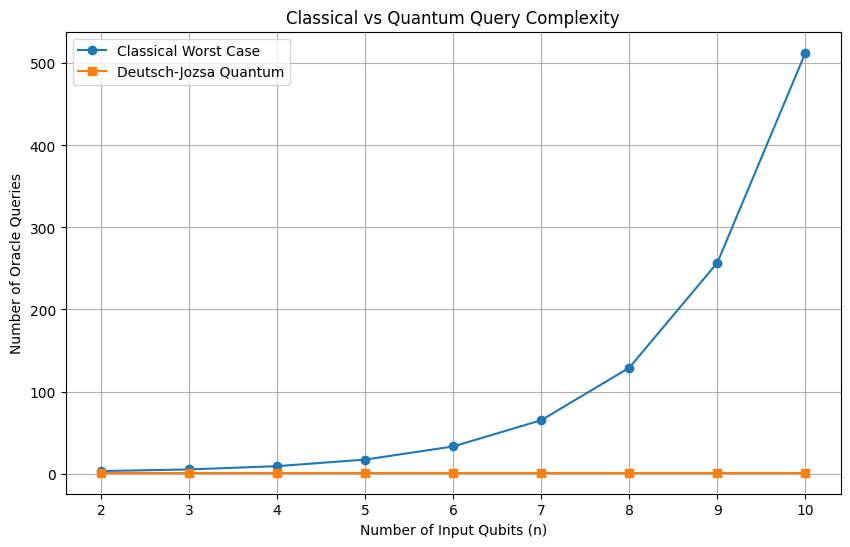

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.plot(
    n_values,
    classical_queries,
    marker='o',
    label='Classical Worst Case'
)

plt.plot(
    n_values,
    quantum_queries,
    marker='s',
    label='Deutsch-Jozsa Quantum'
)

plt.xlabel("Number of Input Qubits (n)")
plt.ylabel("Number of Oracle Queries")
plt.title("Classical vs Quantum Query Complexity")
plt.xticks(n_values)
plt.legend()
plt.grid(True)

plt.show()

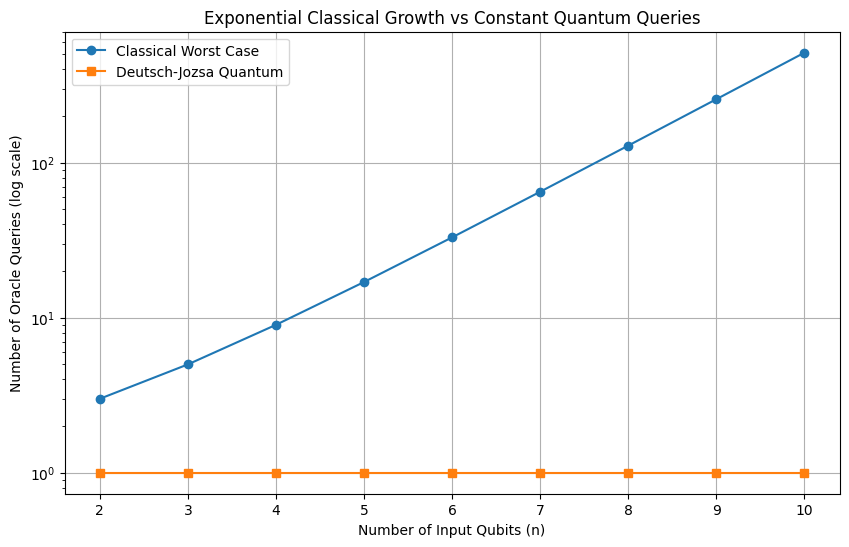

In [15]:
plt.figure(figsize=(10, 6))

plt.semilogy(
    n_values,
    classical_queries,
    marker='o',
    label='Classical Worst Case'
)

plt.semilogy(
    n_values,
    quantum_queries,
    marker='s',
    label='Deutsch-Jozsa Quantum'
)

plt.xlabel("Number of Input Qubits (n)")
plt.ylabel("Number of Oracle Queries (log scale)")
plt.title("Exponential Classical Growth vs Constant Quantum Queries")
plt.xticks(n_values)
plt.legend()
plt.grid(True)

plt.show()

In [16]:
import random


def random_balanced_function(n):
    """
    Generates a random balanced Boolean function.

    Exactly half of the 2^n inputs produce 0
    and exactly half produce 1.
    """

    total_inputs = 2 ** n
    half = total_inputs // 2

    outputs = [0] * half + [1] * half

    random.shuffle(outputs)

    def f(x):
        return outputs[x]

    return f, outputs

In [17]:
n = 3

random_function, outputs = random_balanced_function(n)

random_truth_table = []

for x in range(2 ** n):

    random_truth_table.append({
        "Input": format(x, f'0{n}b'),
        "f(x)": random_function(x)
    })

random_df = pd.DataFrame(random_truth_table)

display(random_df)

print("Number of zeros:", outputs.count(0))
print("Number of ones :", outputs.count(1))

,Input,f(x)
0,000,0
1,001,0
2,010,1
3,011,1
4,100,0
5,101,0
6,110,1
7,111,1


Number of zeros: 4
Number of ones : 4


In [18]:
n = 3

random_function, outputs = random_balanced_function(n)

classification, counts, circuit = deutsch_jozsa(
    random_function,
    n,
    draw_circuit=True
)

print("\nActual function type: Balanced")
print("Deutsch-Jozsa result:", classification)
print("Measurement results:", counts)

     ┌───┐      ░ ┌───┐     ┌───┐                                    ░ ┌───┐┌─┐»
q_0: ┤ H ├──────░─┤ X ├──■──┤ X ├───────■──────────────■─────────■───░─┤ H ├┤M├»
     ├───┤      ░ └───┘  │  ├───┤       │  ┌───┐┌───┐  │  ┌───┐  │   ░ ├───┤└╥┘»
q_1: ┤ H ├──────░────────■──┤ X ├───────■──┤ X ├┤ X ├──■──┤ X ├──■───░─┤ H ├─╫─»
     ├───┤      ░ ┌───┐  │  ├───┤┌───┐  │  ├───┤└───┘  │  └───┘  │   ░ ├───┤ ║ »
q_2: ┤ H ├──────░─┤ X ├──■──┤ X ├┤ X ├──■──┤ X ├───────■─────────■───░─┤ H ├─╫─»
     ├───┤┌───┐ ░ └───┘┌─┴─┐└───┘└───┘┌─┴─┐└───┘     ┌─┴─┐     ┌─┴─┐ ░ └───┘ ║ »
q_3: ┤ X ├┤ H ├─░──────┤ X ├──────────┤ X ├──────────┤ X ├─────┤ X ├─░───────╫─»
     └───┘└───┘ ░      └───┘          └───┘          └───┘     └───┘ ░       ║ »
c: 3/════════════════════════════════════════════════════════════════════════╩═»
                                                                             0 »
«           
«q_0: ──────
«     ┌─┐   
«q_1: ┤M├───
«     └╥┘┌─┐
«q_2: ─╫─┤M├
«      ║ └╥┘
«q_3: ─╫──╫─
«    

In [19]:
n = 3
number_of_trials = 10

verification_results = []

for trial in range(1, number_of_trials + 1):

    random_function, outputs = random_balanced_function(n)

    classification, counts, _ = deutsch_jozsa(
        random_function,
        n
    )

    correct = classification == "Balanced"

    verification_results.append({
        "Trial": trial,
        "Expected": "Balanced",
        "Detected": classification,
        "Correct": correct,
        "Measurement": str(counts)
    })


verification_df = pd.DataFrame(verification_results)

display(verification_df)

print(
    "\nAll trials classified correctly:",
    verification_df["Correct"].all()
)

,Trial,Expected,Detected,Correct,Measurement
0,1,Balanced,Balanced,True,"{'111': 236, '010': 249, '100': 270, '001': 269}"
1,2,Balanced,Balanced,True,"{'101': 243, '001': 244, '010': 267, '110': 270}"
2,3,Balanced,Balanced,True,"{'011': 254, '110': 257, '001': 281, '100': 232}"
3,4,Balanced,Balanced,True,"{'011': 236, '100': 240, '101': 268, '010': 280}"
4,5,Balanced,Balanced,True,"{'001': 260, '111': 247, '011': 244, '101': 273}"
5,6,Balanced,Balanced,True,"{'011': 244, '110': 258, '100': 278, '001': 244}"
6,7,Balanced,Balanced,True,"{'001': 243, '100': 267, '011': 232, '110': 282}"
7,8,Balanced,Balanced,True,"{'010': 252, '011': 244, '100': 272, '101': 256}"
8,9,Balanced,Balanced,True,"{'001': 261, '111': 251, '010': 262, '100': 250}"
9,10,Balanced,Balanced,True,"{'111': 291, '011': 267, '010': 234, '110': 232}"



All trials classified correctly: True


In [20]:
random_test_results = []

for n in range(2, 6):

    trials = 5
    correct_count = 0

    for trial in range(trials):

        random_function, outputs = random_balanced_function(n)

        classification, counts, _ = deutsch_jozsa(
            random_function,
            n
        )

        if classification == "Balanced":
            correct_count += 1

    accuracy = (correct_count / trials) * 100

    random_test_results.append({
        "n": n,
        "Trials": trials,
        "Correct Classifications": correct_count,
        "Accuracy (%)": accuracy
    })


random_test_df = pd.DataFrame(random_test_results)

display(random_test_df)

,n,Trials,Correct Classifications,Accuracy (%)
0,2,5,5,100.0
1,3,5,5,100.0
2,4,5,5,100.0
3,5,5,5,100.0


In [21]:
print("=" * 65)
print("        DEUTSCH-JOZSA ALGORITHM - FINAL VERIFICATION")
print("=" * 65)

# --------------------------------------------------
# Constant function
# --------------------------------------------------

n = 3

constant_result, constant_counts, _ = deutsch_jozsa(
    constant_zero,
    n
)

print("\n1. CONSTANT FUNCTION")
print("--------------------")
print("Number of input qubits:", n)
print("Classification:", constant_result)
print("Measurement:", constant_counts)


# --------------------------------------------------
# Balanced parity function
# --------------------------------------------------

balanced_result, balanced_counts, _ = deutsch_jozsa(
    parity_function,
    n
)

print("\n2. BALANCED PARITY FUNCTION")
print("----------------------------")
print("Number of input qubits:", n)
print("Classification:", balanced_result)
print("Measurement:", balanced_counts)


# --------------------------------------------------
# Random balanced function
# --------------------------------------------------

random_f, _ = random_balanced_function(n)

random_result, random_counts, _ = deutsch_jozsa(
    random_f,
    n
)

print("\n3. RANDOM BALANCED FUNCTION")
print("---------------------------")
print("Number of input qubits:", n)
print("Classification:", random_result)
print("Measurement:", random_counts)


print("\n" + "=" * 65)
print("VERIFICATION COMPLETED SUCCESSFULLY")
print("=" * 65)

        DEUTSCH-JOZSA ALGORITHM - FINAL VERIFICATION

1. CONSTANT FUNCTION
--------------------
Number of input qubits: 3
Classification: Constant
Measurement: {'000': 1024}

2. BALANCED PARITY FUNCTION
----------------------------
Number of input qubits: 3
Classification: Balanced
Measurement: {'111': 1024}

3. RANDOM BALANCED FUNCTION
---------------------------
Number of input qubits: 3
Classification: Balanced
Measurement: {'011': 239, '001': 276, '100': 260, '110': 249}

VERIFICATION COMPLETED SUCCESSFULLY
